In [56]:
# conda env: cache5(Python 3.11.8)
import os
import pandas as pd
import numpy as np

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, rdFMCS, PandasTools, Draw, PandasTools
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import SVG, display, Image

# inner imports
from utils.standardizer import standardize_smiles

# PCA or UMAP plotting
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap.umap_ as umap

# Functions

In [90]:
def mol2fp(mol):
    """Convert RDKit Mol to Morgan Fingerprint."""
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

def preprocess_hits(df):
    """Process VS hits DataFrame to standardize SMILES and compute fingerprints."""
    # column: 'canonical_smiles_by_Std'
    df = standardize_smiles(df) 
    df = df.drop(columns=['SMILES']) # remove column: 'SMILES'
    # column: 'RDMol' and 'fp'
    df['RDMol'] = [Chem.MolFromSmiles(smiles) for smiles in df['canonical_smiles_by_Std']]
    df['fp'] = df['RDMol'].apply(mol2fp)
    # column: 'BM_scaffold' and 'BM_scaffold_smiles'
    # Bemis and Murcko methods: dissect a molecule into four parts: ring systems, linkers, side chains, 
    # and the Murcko framework that is the union of ring systems and linkers in a molecule.
    df['RDscaffold'] = df['RDMol'].apply(lambda mol: MurckoScaffold.GetScaffoldForMol(mol))
    df['generic_scaffold'] = df['RDscaffold'].apply(lambda mol: MurckoScaffold.MakeScaffoldGeneric(mol))
    df['scaffold_smiles'] = df['RDscaffold'].apply(lambda mol: Chem.MolToSmiles(mol))
    df['scaffold_fp'] = df['RDscaffold'].apply(mol2fp)

    return df

def display_2D_structure(df):
    img = Draw.MolsToGridImage(df['RDMol'].to_list(),
                               legends=df['Compound'].to_list(),
                                molsPerRow=4,
                                subImgSize=(200, 150))
    img_scaffold = Draw.MolsToGridImage(df['RDscaffold'].to_list(),
                                        # append 'BM' to the legend to distinguish from the original compound
                                        legends=[f"scaffold_{name}" for name in df['Compound'].to_list()],
                                        #legends=df['Compound'].to_list(),
                                        molsPerRow=4,
                                        subImgSize=(200, 150))
    img_generic_scaffold = Draw.MolsToGridImage(df['generic_scaffold'].to_list(),
                                        legends=[f"generic_scaffold_{name}" for name in df['Compound'].to_list()],
                                        molsPerRow=4,
                                        subImgSize=(200, 150))
    display(img)
    display(img_scaffold)
    display(img_generic_scaffold)

# Read Data

## vs_hits_df
for hits selected in virtual screening

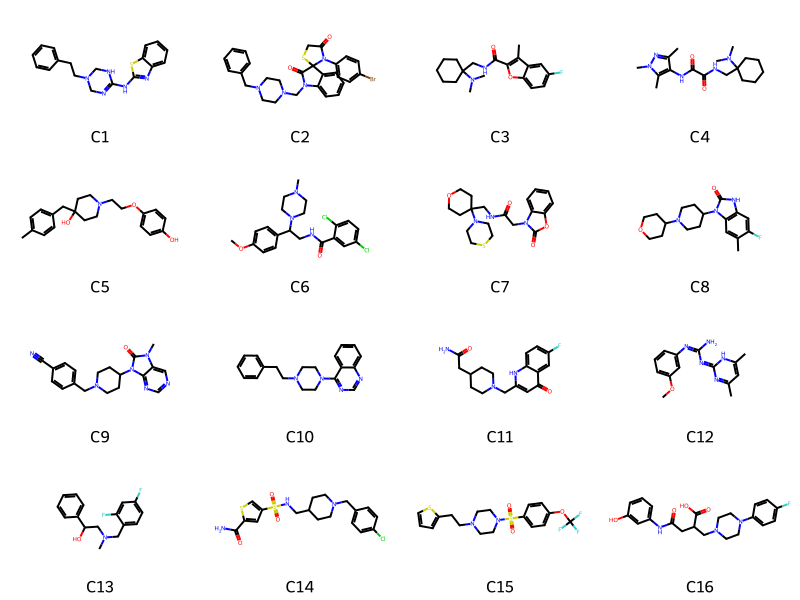

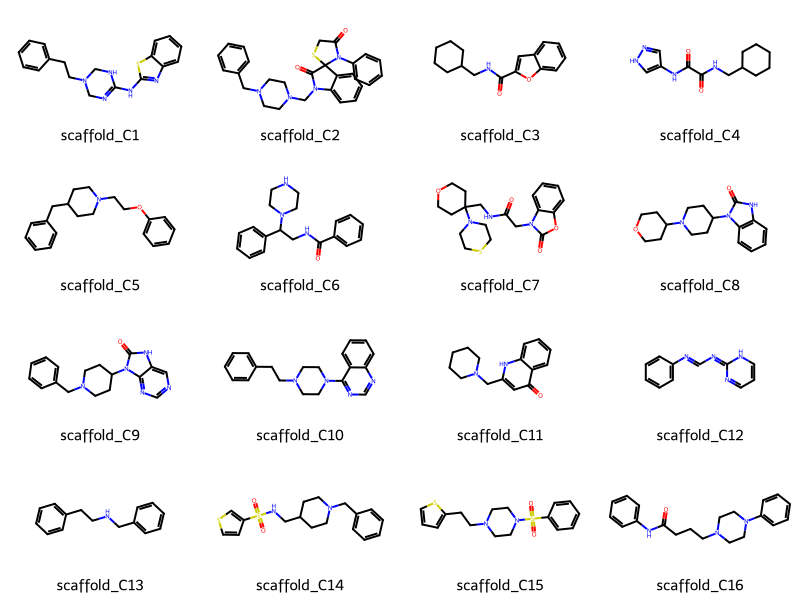

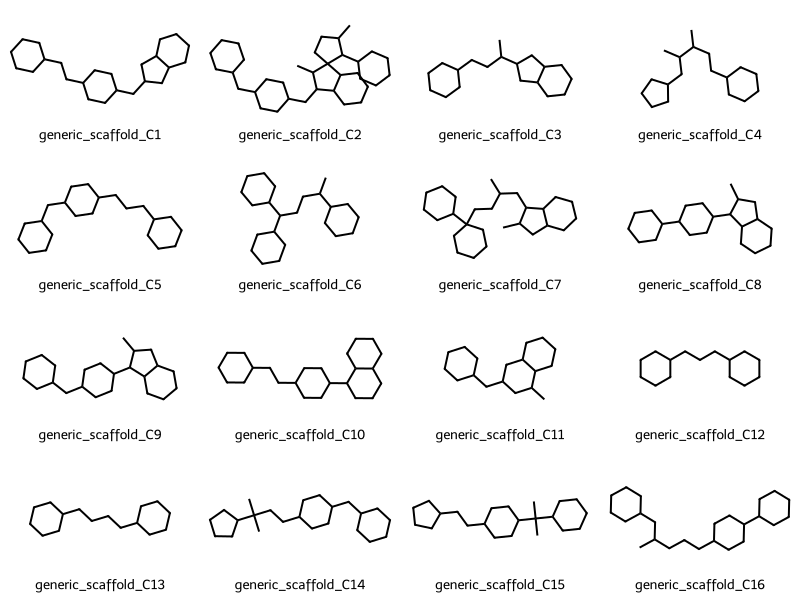

,Compound,canonical_smiles_by_Std,RDMol,fp,RDscaffold,generic_scaffold,scaffold_smiles,scaffold_fp
0,C1,c1ccc(CCN2CN=C(Nc3nc4ccccc4s3)NC2)cc1,<rdkit.Chem.rdchem.Mol object at 0x35e90d150>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.Chem.rdchem.Mol object at 0x3ed1945f0>,<rdkit.Chem.rdchem.Mol object at 0x3ed1954d0>,c1ccc(CCN2CN=C(Nc3nc4ccccc4s3)NC2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [91]:
vs_hits_df = pd.DataFrame({
    'Compound': ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16'],
    'SMILES': [
        'C1(CCN2CN=C(NC3=NC4=CC=CC=C4S3)NC2)=CC=CC=C1', # Compound 1
        'BrC1=CC=C(N2C(CSC(C3=O)2C4=CC=CC=C4N3CN5CCN(CC6=CC=CC=C6)CC5)=O)C=C1', # Compound 2
        'CC(C1=C(O2)C=CC(F)=C1)=C2C(NCC3(N(C)C)CCCCC3)=O', # Compound 3
        'CC1=NN(C(C)=C1NC(C(NCC2(N(C)C)CCCCC2)=O)=O)C', # Compound 4
        'CC1=CC=C(CC2(O)CCN(CCOC3=CC=C(O)C=C3)CC2)C=C1', # Compound 5
        'CN1CCN(C(C2=CC=C(OC)C=C2)CNC(C3=C(Cl)C=CC(Cl)=C3)=O)CC1', # Compound 6
        'O=C(NCC1(N2CCSCC2)CCOCC1)CN3C4=CC=CC=C4OC3=O', # Compound 7
        'CC1=CC2=C(N=C(O)N2C3CCN(C4CCOCC4)CC3)C=C1F', # Compound 8
        'CN(C1=O)C2=CN=CN=C2N1C3CCN(CC4=CC=C(C#N)C=C4)CC3', # Compound 9
        'C1(CCN2CCN(C3=NC=NC4=CC=CC=C43)CC2)=CC=CC=C1', # Compound 10
        'FC1=CC(C(C=C(N2)CN3CCC(CC(O)=N)CC3)=O)=C2C=C1', # Compound 11
        'CC1=CC(C)=NC(NC(NC2=CC(OC)=CC=C2)=N)=N1', # Compound 12
        'CN(CC(O)C1=CC=CC=C1)CC2=C(F)C=C(F)C=C2', # Compound 13
        'ClC1=CC=C(CN2CCC(CNS(C3=CSC(C(N)=O)=C3)(=O)=O)CC2)C=C1', # Compound 14
        'FC(F)(OC1=CC=C(S(N2CCN(CC2)CCC3=CC=CS3)(=O)=O)C=C1)F', # Compound 15
        'FC1=CC=C(N2CCN(CC(C(O)=O)CC(NC3=CC(O)=CC=C3)=O)CC2)C=C1' # Compound 16
    ]
})

vs_hits_df = preprocess_hits(vs_hits_df)
display_2D_structure(vs_hits_df)
vs_hits_df.head(1)

## exp_hits_df
for hits confirmed by experimental assays

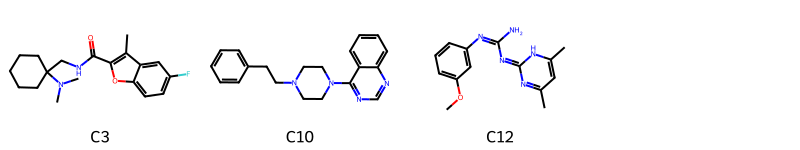

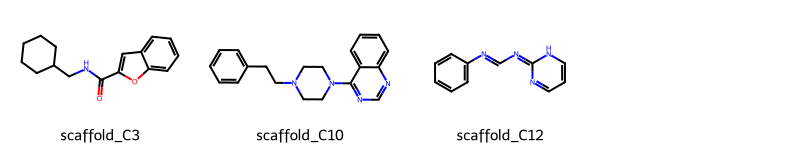

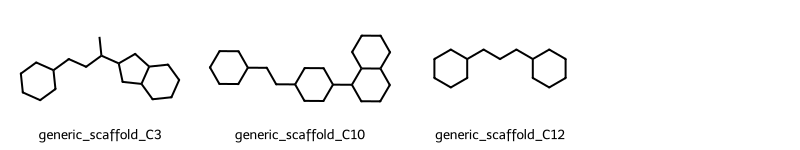

,Compound,canonical_smiles_by_Std,RDMol,fp,RDscaffold,generic_scaffold,scaffold_smiles,scaffold_fp
0,C3,Cc1c(C(=O)NCC2(N(C)C)CCCCC2)oc2ccc(F)cc12,<rdkit.Chem.rdchem.Mol object at 0x35bcb4a50>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.Chem.rdchem.Mol object at 0x3ed196570>,<rdkit.Chem.rdchem.Mol object at 0x3ed1963b0>,O=C(NCC1CCCCC1)c1cc2ccccc2o1,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [92]:
exp_hits_df = pd.DataFrame({
    'Compound': ['C3', 'C10', 'C12'],
    'SMILES': ['CC(C1=C(O2)C=CC(F)=C1)=C2C(NCC3(N(C)C)CCCCC3)=O', # Compound 3
                'C1(CCN2CCN(C3=NC=NC4=CC=CC=C43)CC2)=CC=CC=C1', # Compound 10
                'CC1=CC(C)=NC(NC(NC2=CC(OC)=CC=C2)=N)=N1', # Compound 12
                ], 
    })

exp_hits_df = preprocess_hits(exp_hits_df)
display_2D_structure(exp_hits_df)
exp_hits_df.head(1)

## or_df

In [61]:
OR_chemblids_name = {'CHEMBL233':'mor', 'CHEMBL237':'kor', 'CHEMBL236':'dor', 'CHEMBL2014':'nor'}

In [62]:
# mor
mor_ec50 = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL233_None_None_EC50_None_hhd_b50_b50_curated.csv'))
mor_ic50 = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL233_None_None_IC50_None_hhd_b50_b50_curated.csv'))
mor_ki = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL233_None_None_Ki_None_hhd_b50_b50_curated.csv'))

# kor
kor_ec50 = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL237_None_None_EC50_None_hhd_b50_b50_curated.csv'))
kor_ic50 = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL237_None_None_IC50_None_hhd_b50_b50_curated.csv'))
kor_ki = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL237_None_None_Ki_None_hhd_b50_b50_curated.csv'))

# dor
dor_ec50 = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL236_None_None_EC50_None_hhd_b50_b50_curated.csv'))
dor_ic50 = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL236_None_None_IC50_None_hhd_b50_b50_curated.csv'))
dor_ki = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL236_None_None_Ki_None_hhd_b50_b50_curated.csv'))

# nor
nor_ec50 = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL2014_None_None_EC50_None_hhd_b50_b50_curated.csv'))
nor_ic50 = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL2014_None_None_IC50_None_hhd_b50_b50_curated.csv'))
nor_ki = pd.read_csv(os.path.join('chembl_or_ligs', 'CHEMBL2014_None_None_Ki_None_hhd_b50_b50_curated.csv'))

print(f'mor_ec50: {mor_ec50.shape}, mor_ic50: {mor_ic50.shape}, mor_ki: {mor_ki.shape}')
print(f'kor_ec50: {kor_ec50.shape}, kor_ic50: {kor_ic50.shape}, kor_ki: {kor_ki.shape}')
print(f'dor_ec50: {dor_ec50.shape}, dor_ic50: {dor_ic50.shape}, dor_ki: {dor_ki.shape}')
print(f'nor_ec50: {nor_ec50.shape}, nor_ic50: {nor_ic50.shape}, nor_ki: {nor_ki.shape}')

mor_ec50: (1954, 50), mor_ic50: (1201, 50), mor_ki: (5258, 50)
kor_ec50: (1656, 50), kor_ic50: (910, 50), kor_ki: (4467, 50)
dor_ec50: (953, 50), dor_ic50: (1039, 50), dor_ki: (4654, 50)
nor_ec50: (221, 50), nor_ic50: (641, 50), nor_ki: (1292, 50)


In [64]:
mor_ec50.columns

Index(['activity_id', 'assay_id', 'assay_chembl_id', 'tid', 'target_chembl_id',
       'standard_type', 'standard_relation', 'standard_value',
       'standard_units', 'pchembl_value', 'assay_type',
       'assay_type_description', 'assay_category', 'assay_organism',
       'assay_tax_id', 'assay_strain', 'assay_tissue', 'assay_cell_type',
       'assay_subcellular_fraction', 'bao_format', 'bao_label', 'variant_id',
       'assay_test_type', 'assay_description', 'cell_id', 'tissue_id',
       'curated_by', 'aidx', 'confidence_score',
       'confidence_score_description', 'molregno', 'compound_chembl_id',
       'pref_name', 'canonical_smiles', 'assay_metadata_hash',
       'canonical_smiles_by_Std', 'molecular_weight', 'num_atoms',
       'pStandard_value', 'vs_activity_comment', 'vs_activity', 'vs_threshold',
       'lo_activity_comment', 'lo_activity', 'lo_threshold', 'stereoSiblings',
       'effect', 'assay', 'effect_description', 'assay_keywords_description'],
      dtype='object

In [65]:
or_all_df = pd.concat([mor_ec50, mor_ic50, mor_ki,
                       kor_ec50, kor_ic50, kor_ki,
                       dor_ec50, dor_ic50, dor_ki,
                       nor_ec50, nor_ic50, nor_ki], ignore_index=True)
print(f'or_all_df: {or_all_df.shape}')

columns_needed = ['assay_chembl_id', 'target_chembl_id', 'compound_chembl_id', 'pref_name', 
                  'standard_type', 'standard_relation', 'standard_value', 'standard_units',
                  'canonical_smiles_by_Std', 'vs_activity_comment' ]

or_df = or_all_df[columns_needed]

# column: 'RDMol' and 'fp'
or_df['RDMol'] = [Chem.MolFromSmiles(smiles) for smiles in or_df['canonical_smiles_by_Std']]
or_df['fp'] = or_df['RDMol'].apply(mol2fp)

# column: 'RD_scaffold' and 'RD_scaffold_smiles'
or_df['RDscaffold'] = or_df['RDMol'].apply(lambda mol: MurckoScaffold.GetScaffoldForMol(mol))
or_df['scaffold_smiles'] = or_df['RDscaffold'].apply(lambda mol: Chem.MolToSmiles(mol))
or_df['scaffold_fp'] = or_df['RDscaffold'].apply(mol2fp)

or_df.head(2)

or_all_df: (24246, 50)


/var/folders/zr/m3987s994pn5dt17r471mfbr0000gn/T/ipykernel_703/2566874786.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  or_df['RDMol'] = [Chem.MolFromSmiles(smiles) for smiles in or_df['canonical_smiles_by_Std']]
/var/folders/zr/m3987s994pn5dt17r471mfbr0000gn/T/ipykernel_703/2566874786.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  or_df['fp'] = or_df['RDMol'].apply(mol2fp)
/var/folders/zr/m3987s994pn5dt17r471mfbr0000gn/T/ipykernel_703/2566874786.py:18: SettingWithCopyWarning: 
A value is tryin

,assay_chembl_id,target_chembl_id,compound_chembl_id,pref_name,standard_type,standard_relation,standard_value,standard_units,canonical_smiles_by_Std,vs_activity_comment,RDMol,fp,RDscaffold,scaffold_smiles,scaffold_fp
0,CHEMBL749654,CHEMBL233,CHEMBL1161413,NaN,EC50,=,49.0,nM,Cc1cc(O)cc(C)c1C[C@H](N)[C@H](O)C/C=C/[C@H](O)...,active,<rdkit.Chem.rdchem.Mol object at 0x31176a180>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.Chem.rdchem.Mol object at 0x3bbc86ab0>,O=C(NCCc1ccccc1)[C@@H](C/C=C/CCCCc1ccccc1)Cc1c...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CHEMBL749654,CHEMBL233,CHEMBL1161419,NaN,EC50,=,31.0,nM,NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](Cc1ccccc1)NC...,active,<rdkit.Chem.rdchem.Mol object at 0x311769620>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.Chem.rdchem.Mol object at 0x3bbc86b20>,O=C(NCCc1ccccc1)[C@H](Cc1ccccc1)NC(=O)[C@H]1CC...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


# Check Novelty

## 1. Duplicate Check by Canonical SMILES

### 1.1 for the compound

In [67]:
vs_hits= list(zip(vs_hits_df['Compound'], vs_hits_df['canonical_smiles_by_Std'], vs_hits_df['scaffold_smiles']))
exp_hits = list(zip(exp_hits_df['Compound'], exp_hits_df['canonical_smiles_by_Std'], exp_hits_df['scaffold_smiles']))

for name, smi, _ in exp_hits:
    if smi in or_df['canonical_smiles_by_Std'].tolist():
        print(f'{name} has been reported in ChEMBL: {smi}')
    else:
        print(f'{name} is a novel compound: {smi}')

C3 is a novel compound: Cc1c(C(=O)NCC2(N(C)C)CCCCC2)oc2ccc(F)cc12
C10 is a novel compound: c1ccc(CCN2CCN(c3ncnc4ccccc34)CC2)cc1
C12 is a novel compound: COc1cccc(N=C(N)N=c2nc(C)cc(C)[nH]2)c1


### 1.2 for Murcko scaffolds of the compound

In [68]:
for name, _, bm_smi in exp_hits:
    if bm_smi in or_df['scaffold_smiles'].tolist():
        print(f'The scaffold of {name} has been reported in ChEMBL: {bm_smi}')
    else:
        print(f'The scaffold of {name} is novel: {bm_smi}')

The scaffold of C3 is novel: O=C(NCC1CCCCC1)c1cc2ccccc2o1
The scaffold of C10 is novel: c1ccc(CCN2CCN(c3ncnc4ccccc34)CC2)cc1
The scaffold of C12 is novel: C(=Nc1ccccc1)N=c1nccc[nH]1


## 2. Similarity Check by Fingerprints
by canonical SMILES for Murcko scaffolds of the compound

In [74]:
exp_hits_name = exp_hits_df['Compound'].tolist()
exp_hits_fp = exp_hits_df['fp'].tolist() 

for name, fp in zip(exp_hits_name, exp_hits_fp):
    or_df[f'{name}_Tc'] = or_df['fp'].apply(lambda x: DataStructs.TanimotoSimilarity(fp, x))

for name, fp in zip(exp_hits_name, exp_hits_fp):
    or_df[f'{name}_scaffold_Tc'] = or_df['scaffold_fp'].apply(lambda x: DataStructs.TanimotoSimilarity(fp, x))

/var/folders/zr/m3987s994pn5dt17r471mfbr0000gn/T/ipykernel_703/534060652.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  or_df[f'{name}_Tc'] = or_df['fp'].apply(lambda x: DataStructs.TanimotoSimilarity(fp, x))
/var/folders/zr/m3987s994pn5dt17r471mfbr0000gn/T/ipykernel_703/534060652.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  or_df[f'{name}_scaffold_Tc'] = or_df['scaffold_fp'].apply(lambda x: DataStructs.TanimotoSimilarity(fp, x))
/var/folders/zr/m3987s994pn5dt17r471mfbr0000gn/T/ipykernel_703/534

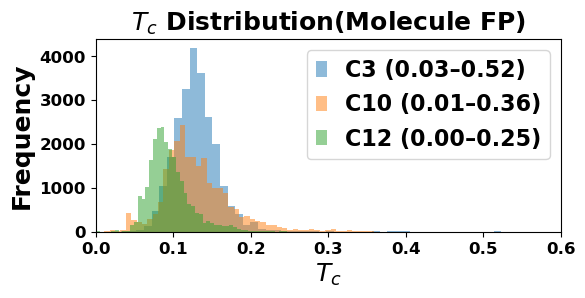

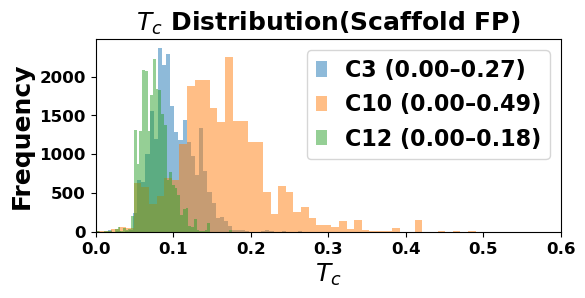

In [ ]:
def hist_Tc(fp_type='Molecule',
            label_fs=18,     # x/y label font size
            title_fs=18,     # title font size
            legend_fs=16,    # legend font size
            tick_fs=12):
    if fp_type == 'Molecule':
        col_3C = f'C3_Tc'
        col_10C = f'C10_Tc'
        col_12C = f'C12_Tc'
    elif fp_type == 'Scaffold':
        col_3C = f'C3_scaffold_Tc'
        col_10C = f'C10_scaffold_Tc'
        col_12C = f'C12_scaffold_Tc'
    else:
        raise ValueError("fp_type must be either 'molecule' or 'scaffold'")
    
    plt.figure(figsize=(6,2.5))

    plt.hist(or_df[col_3C], bins=50, alpha=0.5, label=f'C3 ({or_df[col_3C].min():.2f}–{or_df[col_3C].max():.2f})')
    plt.hist(or_df[col_10C], bins=50, alpha=0.5, label=f'C10 ({or_df[col_10C].min():.2f}–{or_df[col_10C].max():.2f})')
    plt.hist(or_df[col_12C], bins=50, alpha=0.5, label=f'C12 ({or_df[col_12C].min():.2f}–{or_df[col_12C].max():.2f})')

    # set x_axis limit
    plt.xlim(0.0, 0.6)

    plt.xlabel('$T_c$', fontsize=label_fs, fontweight='bold')
    plt.ylabel('Frequency', fontsize=label_fs, fontweight='bold')
    plt.title(f'$T_c$ Distribution({fp_type} FP)', fontsize=title_fs, fontweight='bold')
    plt.legend(prop={'size': legend_fs, 'weight': 'bold'}, handlelength=0.5)
     # set tick label size (scale labels)
    plt.tick_params(axis='both', labelsize=tick_fs)
    # bold tick labels
    for tick in plt.gca().get_xticklabels():
        tick.set_fontweight('bold')

    for tick in plt.gca().get_yticklabels():
        tick.set_fontweight('bold')

    plt.savefig(f"Tc_{fp_type.lower()}_fp.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.show()


hist_Tc(fp_type='Molecule')
hist_Tc(fp_type='Scaffold')

### 2.1 for the compound

#### sorted by C3_Tc

In [ ]:
# sort concat_df by column 'C3_Tc' descendingly
col_4C3 = ['assay_chembl_id', 'target_chembl_id', 'compound_chembl_id', 'pref_name', 
           'standard_type', 'standard_relation', 'standard_value', 'standard_units',
           'C3_Tc']

or_df_C3 = or_df[col_4C3].sort_values(by='C3_Tc', ascending=False)
or_df_C3.head(10)

,assay_chembl_id,target_chembl_id,compound_chembl_id,pref_name,standard_type,standard_relation,standard_value,standard_units,C3_Tc
14917,CHEMBL4050969,CHEMBL237,CHEMBL4077345,NaN,Ki,=,660.00,nM,0.523077
14892,CHEMBL4050969,CHEMBL237,CHEMBL4077345,NaN,Ki,=,645.65,nM,0.523077
14919,CHEMBL4050969,CHEMBL237,CHEMBL1701606,NaN,Ki,=,520.00,nM,0.402778
14894,CHEMBL4050969,CHEMBL237,CHEMBL1701606,NaN,Ki,=,512.86,nM,0.402778
14915,CHEMBL4050969,CHEMBL237,CHEMBL4083805,NaN,Ki,=,720.00,nM,0.391892
14890,CHEMBL4050969,CHEMBL237,CHEMBL4083805,NaN,Ki,=,707.95,nM,0.391892
14936,CHEMBL4050969,CHEMBL237,CHEMBL1875314,NaN,Ki,=,1100.00,nM,0.380282
14911,CHEMBL4050969,CHEMBL237,CHEMBL1875314,NaN,Ki,=,1122.02,nM,0.380282
14920,CHEMBL4050969,CHEMBL237,CHEMBL4078777,NaN,Ki,=,380.00,nM,0.357143
14895,CHEMBL4050969,CHEMBL237,CHEMBL4078777,NaN,Ki,=,363.08,nM,0.357143


#### sorted by C10_Tc

In [72]:
col_4C10 = ['assay_chembl_id', 'target_chembl_id', 'compound_chembl_id', 'pref_name',
            'standard_type', 'standard_relation', 'standard_value', 'standard_units',
            'C10_Tc']
or_df_C10 = or_df[col_4C10].sort_values(by='C10_Tc', ascending=False)
or_df_C10.head(10)

,assay_chembl_id,target_chembl_id,compound_chembl_id,pref_name,standard_type,standard_relation,standard_value,standard_units,C10_Tc
8368,CHEMBL5232354,CHEMBL233,CHEMBL5271326,NaN,Ki,<,100.0,nM,0.358491
8245,CHEMBL5110290,CHEMBL233,CHEMBL5186423,NaN,Ki,=,271.3,nM,0.350877
8246,CHEMBL5110290,CHEMBL233,CHEMBL5188409,NaN,Ki,=,555.3,nM,0.350877
8255,CHEMBL5110290,CHEMBL233,CHEMBL5187144,NaN,Ki,=,169.7,nM,0.338983
8259,CHEMBL5110290,CHEMBL233,CHEMBL5187961,NaN,Ki,=,64.6,nM,0.333333
1542,CHEMBL4676428,CHEMBL233,CHEMBL4754601,NaN,EC50,>,1000.0,nM,0.333333
8034,CHEMBL4676429,CHEMBL233,CHEMBL4754601,NaN,Ki,>,1000.0,nM,0.333333
1236,CHEMBL4356649,CHEMBL233,CHEMBL4461864,NaN,EC50,>,1000.0,nM,0.333333
7743,CHEMBL4356647,CHEMBL233,CHEMBL4461864,NaN,Ki,=,401.0,nM,0.333333
8370,CHEMBL5232354,CHEMBL233,CHEMBL5284021,NaN,Ki,=,100.0,nM,0.333333


#### sorted by C12_Tc

In [73]:
col_4C12 = ['assay_chembl_id', 'target_chembl_id', 'compound_chembl_id', 'pref_name',
            'standard_type', 'standard_relation', 'standard_value', 'standard_units',
            'C12_Tc']
or_df_C12 = or_df[col_4C12].sort_values(by='C12_Tc', ascending=False)
or_df_C12.head(10)

,assay_chembl_id,target_chembl_id,compound_chembl_id,pref_name,standard_type,standard_relation,standard_value,standard_units,C12_Tc
4132,CHEMBL869296,CHEMBL233,CHEMBL212510,NaN,Ki,>,10000.0,nM,0.246154
11899,CHEMBL869298,CHEMBL237,CHEMBL212510,NaN,Ki,>,10000.0,nM,0.246154
18808,CHEMBL869294,CHEMBL236,CHEMBL212510,NaN,Ki,>,10000.0,nM,0.246154
4134,CHEMBL869296,CHEMBL233,CHEMBL379092,NaN,Ki,>,10000.0,nM,0.242424
11901,CHEMBL869298,CHEMBL237,CHEMBL379092,NaN,Ki,>,10000.0,nM,0.242424
18810,CHEMBL869294,CHEMBL236,CHEMBL379092,NaN,Ki,>,10000.0,nM,0.242424
11893,CHEMBL869298,CHEMBL237,CHEMBL211673,NaN,Ki,>,10000.0,nM,0.238806
15740,CHEMBL960863,CHEMBL236,CHEMBL492909,NaN,EC50,=,846.0,nM,0.238806
18802,CHEMBL869294,CHEMBL236,CHEMBL211673,NaN,Ki,>,10000.0,nM,0.238806
4126,CHEMBL869296,CHEMBL233,CHEMBL211673,NaN,Ki,>,10000.0,nM,0.238806


### 2.2 for Murcko scaffolds of the compound

#### sorted by C3_scaffold_Tc

In [80]:
col_4C3 = ['assay_chembl_id', 'target_chembl_id', 'compound_chembl_id', 'pref_name', 
           'standard_type', 'standard_relation', 'standard_value', 'standard_units',
           'C3_scaffold_Tc']

or_df_C3_scaffold = or_df[col_4C3].sort_values(by='C3_scaffold_Tc', ascending=False)
or_df_C3_scaffold.head(10)

,assay_chembl_id,target_chembl_id,compound_chembl_id,pref_name,standard_type,standard_relation,standard_value,standard_units,C3_scaffold_Tc
1752,CHEMBL5033453,CHEMBL233,CHEMBL5085710,NaN,EC50,=,4527.00,nM,0.266667
8128,CHEMBL5033452,CHEMBL233,CHEMBL5085710,NaN,Ki,=,1005.00,nM,0.266667
3642,CHEMBL872654,CHEMBL233,CHEMBL170603,NaN,Ki,=,3350.00,nM,0.243243
11365,CHEMBL752213,CHEMBL237,CHEMBL170603,NaN,Ki,=,940.00,nM,0.243243
22482,CHEMBL867087,CHEMBL2014,CHEMBL370866,NaN,IC50,>,1000.00,nM,0.228916
14915,CHEMBL4050969,CHEMBL237,CHEMBL4083805,NaN,Ki,=,720.00,nM,0.220779
14889,CHEMBL4050969,CHEMBL237,CHEMBL4063789,NaN,Ki,=,912.01,nM,0.220779
14936,CHEMBL4050969,CHEMBL237,CHEMBL1875314,NaN,Ki,=,1100.00,nM,0.220779
14919,CHEMBL4050969,CHEMBL237,CHEMBL1701606,NaN,Ki,=,520.00,nM,0.220779
14914,CHEMBL4050969,CHEMBL237,CHEMBL4063789,NaN,Ki,=,950.00,nM,0.220779


#### sorted by C10_scaffold_Tc

In [176]:
col_4C10 = ['assay_chembl_id', 'target_chembl_id', 'compound_chembl_id', 'pref_name', 
           'standard_type', 'standard_relation', 'standard_value', 'standard_units',
           'C10_scaffold_Tc', 'C10_Tc']

or_df_C10_scaffold = or_df[col_4C10].sort_values(by='C10_scaffold_Tc', ascending=False)
or_df_C10_scaffold.head(20) #174

,assay_chembl_id,target_chembl_id,compound_chembl_id,pref_name,standard_type,standard_relation,standard_value,standard_units,C10_scaffold_Tc,C10_Tc
10889,CHEMBL4040560,CHEMBL237,CHEMBL4061439,NaN,IC50,=,1981.53,nM,0.490196,0.285714
10895,CHEMBL4040560,CHEMBL237,CHEMBL4061439,NaN,IC50,=,1800.00,nM,0.490196,0.285714
3739,CHEMBL751572,CHEMBL233,CHEMBL358089,NaN,Ki,=,433.00,nM,0.463415,0.307692
3733,CHEMBL751572,CHEMBL233,CHEMBL146997,NaN,Ki,=,37.00,nM,0.463415,0.289855
3730,CHEMBL751572,CHEMBL233,CHEMBL147569,NaN,Ki,=,477.00,nM,0.463415,0.289855
3969,CHEMBL881218,CHEMBL233,CHEMBL196071,NaN,Ki,=,33.00,nM,0.463415,0.294118
3970,CHEMBL881218,CHEMBL233,CHEMBL146997,NaN,Ki,=,126.00,nM,0.463415,0.289855
3729,CHEMBL751572,CHEMBL233,CHEMBL147044,NaN,Ki,=,1.04,nM,0.463415,0.289855
3727,CHEMBL751572,CHEMBL233,CHEMBL147949,NaN,Ki,=,23.00,nM,0.463415,0.298507
10898,CHEMBL4040560,CHEMBL237,CHEMBL4084408,NaN,IC50,=,1400.00,nM,0.444444,0.219178


In [ ]:
C10_simScaffold_df = or_df_C10_scaffold.head(173)

C10_simScaffold_df['target_chembl_id'].value_counts()


target_chembl_id
CHEMBL233     97
CHEMBL236     38
CHEMBL237     37
CHEMBL2014     1
Name: count, dtype: int64

In [173]:
C10_simScaffold_df['assay_chembl_id'].value_counts()

assay_chembl_id
CHEMBL4308248    10
CHEMBL4040560     8
CHEMBL866455      8
CHEMBL866453      8
CHEMBL866454      8
CHEMBL4308247     8
CHEMBL753397      8
CHEMBL866380      8
CHEMBL751574      7
CHEMBL756180      7
CHEMBL4410977     7
CHEMBL855304      6
CHEMBL751572      6
CHEMBL752204      6
CHEMBL754686      5
CHEMBL751203      5
CHEMBL752139      4
CHEMBL864530      4
CHEMBL961055      3
CHEMBL4706147     2
CHEMBL5227857     2
CHEMBL4371113     2
CHEMBL881218      2
CHEMBL900980      2
CHEMBL5227856     2
CHEMBL909317      1
CHEMBL1074666     1
CHEMBL751204      1
CHEMBL909853      1
CHEMBL5227864     1
CHEMBL5227866     1
CHEMBL909851      1
CHEMBL909312      1
CHEMBL757310      1
CHEMBL5227868     1
CHEMBL1074667     1
CHEMBL752205      1
CHEMBL909298      1
CHEMBL756220      1
CHEMBL909313      1
CHEMBL751989      1
CHEMBL755061      1
CHEMBL3756647     1
CHEMBL5110290     1
CHEMBL5046487     1
CHEMBL666289      1
CHEMBL4371114     1
CHEMBL751038      1
CHEMBL757060      1
CHEM

#### sorted by C12_scaffold_Tc

In [88]:
col_4C12 = ['assay_chembl_id', 'target_chembl_id', 'compound_chembl_id', 'pref_name', 
           'standard_type', 'standard_relation', 'standard_value', 'standard_units',
           'C12_scaffold_Tc']

or_df_C12_scaffold = or_df[col_4C12].sort_values(by='C12_scaffold_Tc', ascending=False)
or_df_C12_scaffold.head(10)

,assay_chembl_id,target_chembl_id,compound_chembl_id,pref_name,standard_type,standard_relation,standard_value,standard_units,C12_scaffold_Tc
414,CHEMBL2051429,CHEMBL233,CHEMBL3217000,NaN,EC50,=,1500.00,nM,0.175676
416,CHEMBL2051429,CHEMBL233,CHEMBL3215667,NaN,EC50,=,400.00,nM,0.175676
413,CHEMBL2051429,CHEMBL233,CHEMBL3216999,NaN,EC50,=,340.00,nM,0.175676
5864,CHEMBL2051428,CHEMBL233,CHEMBL3216999,NaN,Ki,=,5.41,nM,0.175676
5865,CHEMBL2051428,CHEMBL233,CHEMBL3217000,NaN,Ki,=,110.00,nM,0.175676
420,CHEMBL2051429,CHEMBL233,CHEMBL3217001,NaN,EC50,=,170.00,nM,0.175676
5868,CHEMBL2051428,CHEMBL233,CHEMBL3215667,NaN,Ki,=,27.00,nM,0.175676
5873,CHEMBL2051428,CHEMBL233,CHEMBL3217001,NaN,Ki,=,7.80,nM,0.175676
22542,CHEMBL871574,CHEMBL2014,CHEMBL212520,NaN,IC50,=,410.00,nM,0.173913
5870,CHEMBL2051428,CHEMBL233,CHEMBL3216560,NaN,Ki,=,42.00,nM,0.173333


## 4. PCA or UMAP

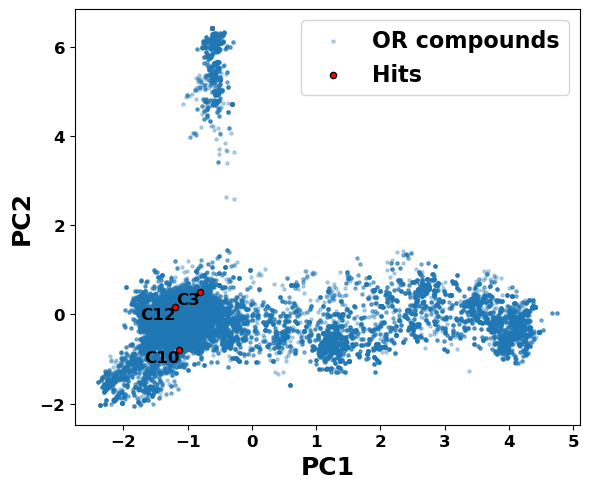

In [138]:
# convert fingerprints to numpy arrays
def fp_to_array(fp):
    arr = np.zeros((1,), dtype=int)
    AllChem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# PCA plotting
def plot_pca(X, X_hits, figname='', X_act=None,
            label_fs=18,     # x/y label font size
            title_fs=18,     # title font size
            legend_fs=16,    # legend font size
            tick_fs=12):
    """Plot PCA of fingerprints."""
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    n_hits = len(X_hits)
    n_act = len(X_act) if X_act is not None else 0

    plt.figure(figsize=(6,5))

    if X_act is not None:
        # inactive MOR ligands
        plt.scatter(
            X_pca[n_hits+n_act:, 0],
            X_pca[n_hits+n_act:, 1],
            alpha=0.2,
            s=5,
            label='Inactive MOR ligands'
        )

        # active MOR ligands
        plt.scatter(
            X_pca[n_hits:n_hits+n_act, 0],
            X_pca[n_hits:n_hits+n_act, 1],
            alpha=0.5,
            s=8,
            label='Active MOR ligands'
        )

        # VS hits
        plt.scatter(
            X_pca[:n_hits, 0],
            X_pca[:n_hits, 1],
            color='red',
            s=20,
            edgecolor='black',
            label='Hits'
        )
    else:
        plt.scatter(
            X_pca[n_hits:,0],
            X_pca[n_hits:,1],
            alpha=0.3,
            s=5,
            label=figname if figname else 'OR ligands'
        )

        plt.scatter(
                X_pca[:n_hits,0],
                X_pca[:n_hits,1],
                color='red',
                s=20,
                edgecolor='black',
                label='Hits'
            )
        # label hits
        for i, name in enumerate(X_names):
            plt.text(
                X_pca[i, 0],
                X_pca[i, 1],
                name,
                fontsize=12,
                ha='right',
                va='top',
                fontweight='bold'
            )

    plt.xlabel('PC1', fontsize=label_fs, fontweight='bold')
    plt.ylabel('PC2', fontsize=label_fs, fontweight='bold')
    plt.legend(prop={'size': legend_fs, 'weight': 'bold'})
    #plt.title(f'Hits in the Chemical Space of OR Compounds', fontsize=title_fs)
    plt.tick_params(axis='both', labelsize=tick_fs)
    for tick in plt.gca().get_xticklabels():
        tick.set_fontweight('bold')

    for tick in plt.gca().get_yticklabels():
        tick.set_fontweight('bold')

    plt.tight_layout()

    plt.savefig(f"PCA.png", dpi=300, bbox_inches="tight")

    plt.show()

def plot_umap(X, X_hits, figname='', X_act=None):
    """Plot UMAP of fingerprints."""
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric='jaccard',
        random_state=42
    )

    X_umap = reducer.fit_transform(X)

    n_hits = len(X_hits)
    n_act = len(X_act) if X_act is not None else 0

    plt.figure(figsize=(6,5))
    
    if X_act is not None:
        # inactive MOR ligands
        plt.scatter(
            X_umap[n_hits+n_act:, 0],
            X_umap[n_hits+n_act:, 1],
            alpha=0.2,
            s=5,
            label='Inactive MOR ligands'
        )

        # active MOR ligands
        plt.scatter(
            X_umap[n_hits:n_hits+n_act, 0],
            X_umap[n_hits:n_hits+n_act, 1],
            alpha=0.5,
            s=8,
            label='Active MOR ligands'
        )

        # VS hits
        plt.scatter(
            X_umap[:n_hits, 0],
            X_umap[:n_hits, 1],
            color='red',
            s=20,
            label='VS hits'
        )
    else:
        plt.scatter(
            X_umap[n_hits:,0],
            X_umap[n_hits:,1],
            alpha=0.3,
            s=5,
            label= figname if figname else 'OR ligands'
        )
        plt.scatter(
            X_umap[:n_hits,0],
            X_umap[:n_hits,1],
            color='red',
            s=20,
            label='VS hits'
        )

        plt.xlabel('UMAP-1')
        plt.ylabel('UMAP-2')
        plt.legend()
        plt.title('UMAP: Chemical Space of VS Hits and ' + figname)
        plt.tight_layout()
        plt.show()

# X_hits
X_hits = np.array([fp_to_array(fp) for fp in exp_hits_df['fp']])
X_names = exp_hits_df['Compound'].tolist()
X_vs_hits = np.array([fp_to_array(fp) for fp in vs_hits_df['fp']])

# X_or
X_or = np.array([fp_to_array(fp) for fp in or_df['fp']])
#X = np.vstack([X_hits, X_or])
X = np.vstack([X_hits, X_or])
plot_pca(X, X_hits, figname='OR compounds')
#plot_umap(X, X_vs_hits, figname='OR compounds')

# # X_mor
# mor_df = concat_df[concat_df['target_chembl_id']=='CHEMBL237']
# X_mor = np.array([fp_to_array(fp) for fp in mor_df['fp']])
# X = np.vstack([X_hits, X_mor])
# plot_pca(X, X_hits, figname='MOR ligands')
# plot_umap(X, X_hits, figname='MOR ligands')
# 
# # X_mor_act
# mor_act_df = mor_df[mor_df['vs_activity_comment']=='active']
# X_mor_act = np.array([fp_to_array(fp) for fp in mor_act_df['fp']])
# X = np.vstack([X_hits, X_mor_act])
# plot_pca(X, X_hits, figname='MOR active ligands')
# plot_umap(X, X_hits, figname='MOR active ligands')
# 
# # X_mor_act/inact
# mor_inact_df = mor_df[mor_df['vs_activity_comment']=='inactive']
# X_mor_inact = np.array([fp_to_array(fp) for fp in mor_inact_df['fp']])
# X = np.vstack([X_hits, X_mor_act, X_mor_inact])
# plot_pca(X, X_hits, figname='MOR active/inactive ligands', X_act=X_mor_act)
# plot_umap(X, X_hits, figname='MOR active/inactive ligands', X_act=X_mor_act)